In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# ***DECISION TREE***

In [ ]:
def gini_impurity(labels):
    """
    Tính Gini Impurity cho một danh sách các nhãn.
    """
    if len(labels) == 0:
        return 0

    label_counts = Counter(labels)
    total_samples = len(labels)

    impurity = 1
    for count in label_counts.values():
        probability = count / total_samples
        impurity -= probability**2
    return impurity

In [ ]:
def find_best_split(X, y):
    """
    Tìm thuộc tính và giá trị chia tốt nhất dựa trên Gini Impurity cho thuộc tính phân loại.

    Args:
        X (np.array): Dữ liệu đầu vào (features).
        y (np.array): Nhãn của dữ liệu.

    Returns:
        tuple: (best_feature_idx, best_split_value, min_gini_impurity_after_split)
               Trả về None nếu không tìm được điểm chia hợp lệ.
    """
    num_features = X.shape[1]
    best_gini = float('inf')
    best_split = None  # Sẽ lưu (feature_idx, split_value)

    for feature_idx in range(num_features):
        unique_values = np.unique(X[:, feature_idx])

        # Thử từng giá trị duy nhất trong cột như một điểm chia
        for split_value in unique_values:
            # Chia dữ liệu thành 2 nhóm:
            # Nhóm 1: feature_value == split_value
            # Nhóm 2: feature_value != split_value

            mask_group1 = (X[:, feature_idx] == split_value)
            mask_group2 = ~mask_group1 # Phần còn lại

            y_group1 = y[mask_group1]
            y_group2 = y[mask_group2]

            # Đảm bảo rằng mỗi nhánh con không rỗng
            if len(y_group1) == 0 or len(y_group2) == 0:
                continue

            gini_group1 = gini_impurity(y_group1)
            gini_group2 = gini_impurity(y_group2)

            # Tính Gini Impurity có trọng số
            weighted_gini = (len(y_group1) / len(y)) * gini_group1 + \
                            (len(y_group2) / len(y)) * gini_group2

            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_split = (feature_idx, split_value)

    return best_split, best_gini

In [ ]:
class Node:
    def __init__(self, feature_idx=None, split_value=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx      # Chỉ số của thuộc tính dùng để chia
        self.split_value = split_value      # Giá trị dùng để chia (feature_value == split_value)
        self.left = left                    # Con trái (khi feature_value == split_value)
        self.right = right                  # Con phải (khi feature_value != split_value)
        self.value = value                  # Giá trị của nút lá (nhãn dự đoán)

In [ ]:
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2, min_impurity_decrease=0.0):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_impurity_decrease = min_impurity_decrease
        self.root = None

    def _build_tree(self, X, y, depth=0):
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))

        # Điều kiện dừng:
        if num_labels == 1: # Tất cả các mẫu trong nút thuộc cùng một lớp
            return Node(value=y[0])

        if self.max_depth is not None and depth >= self.max_depth: # Đạt đến độ sâu tối đa
            most_common_label = Counter(y).most_common(1)[0][0]
            return Node(value=most_common_label)

        if num_samples < self.min_samples_split: # Số lượng mẫu quá ít để chia
            most_common_label = Counter(y).most_common(1)[0][0]
            return Node(value=most_common_label)

        # Tìm điểm chia tốt nhất
        best_split_info, current_gini = find_best_split(X, y)

        if best_split_info is None: # Không tìm được điểm chia hợp lệ
            most_common_label = Counter(y).most_common(1)[0][0]
            return Node(value=most_common_label)

        feature_idx, split_value = best_split_info

        # Kiểm tra sự giảm độ tinh khiết tối thiểu
        # Gini của nút trước khi chia
        gini_before_split = gini_impurity(y)
        if gini_before_split - current_gini < self.min_impurity_decrease:
            most_common_label = Counter(y).most_common(1)[0][0]
            return Node(value=most_common_label)

        # Tạo mặt nạ cho các nhánh con dựa trên giá trị chia
        left_mask = (X[:, feature_idx] == split_value)
        right_mask = ~left_mask # Các mẫu có giá trị khác

        # Xây dựng cây con đệ quy
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        # Trả về nút mới với split_value thay vì threshold
        return Node(feature_idx, split_value, left_child, right_child)

    def fit(self, X, y):
        self.root = self._build_tree(X, y)

    def _predict_one(self, x, node):
        if node.value is not None:  # Nếu là nút lá
            return node.value

        # So sánh giá trị của mẫu với split_value của nút
        if x[node.feature_idx] == node.split_value:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

# ***PREPROCESS***

In [ ]:
lenses = pd.read_csv('/content/lenses.data',sep='\s+',header=None)
lenses.rename(columns={0:'id',1:'age',2:'perscription',3:'astigmatic', 4:'tears',5:'lenses'}, inplace=True)
lenses.head()

,id,age,perscription,astigmatic,tears,lenses
0,1,1,1,1,1,3
1,2,1,1,1,2,2
2,3,1,1,2,1,3
3,4,1,1,2,2,1
4,5,1,2,1,1,3


In [ ]:
lenses.info()
lenses.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            24 non-null     int64
 1   age           24 non-null     int64
 2   perscription  24 non-null     int64
 3   astigmatic    24 non-null     int64
 4   tears         24 non-null     int64
 5   lenses        24 non-null     int64
dtypes: int64(6)
memory usage: 1.3 KB


,id,age,perscription,astigmatic,tears,lenses
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,12.500000,2.000000,1.500000,1.500000,1.500000,2.458333
std,7.071068,0.834058,0.510754,0.510754,0.510754,0.779028
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,6.750000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,12.500000,2.000000,1.500000,1.500000,1.500000,3.000000
75%,18.250000,3.000000,2.000000,2.000000,2.000000,3.000000
max,24.000000,3.000000,2.000000,2.000000,2.000000,3.000000


/tmp/ipython-input-5-1998010316.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=lenses, palette='viridis')


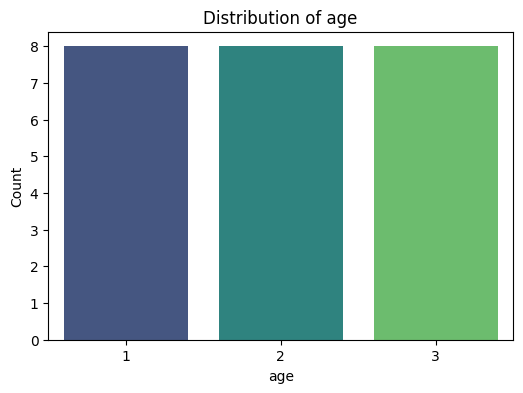

/tmp/ipython-input-5-1998010316.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=lenses, palette='viridis')


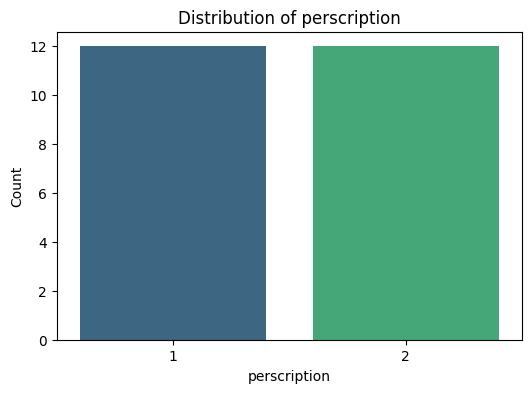

/tmp/ipython-input-5-1998010316.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=lenses, palette='viridis')


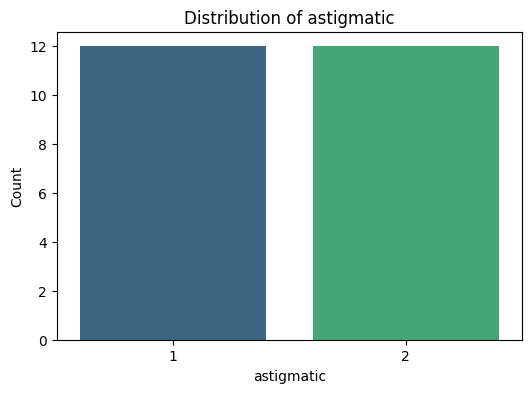

/tmp/ipython-input-5-1998010316.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=lenses, palette='viridis')


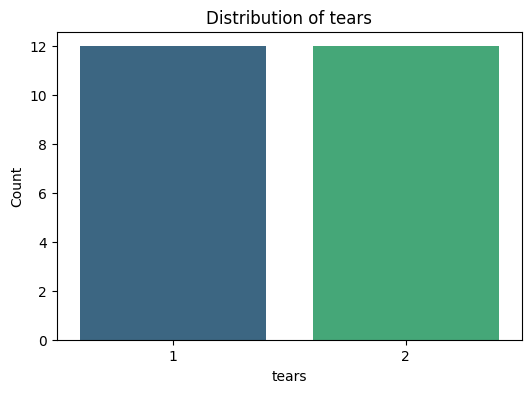

/tmp/ipython-input-5-1998010316.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=lenses, palette='viridis')


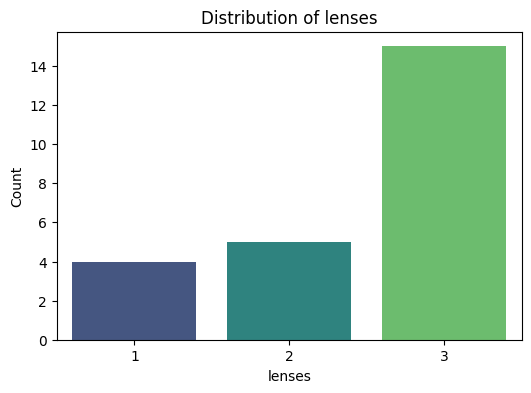

In [ ]:
# Visualize distributions of categorical features
categorical_cols = ['age', 'perscription', 'astigmatic', 'tears', 'lenses']
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=lenses, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

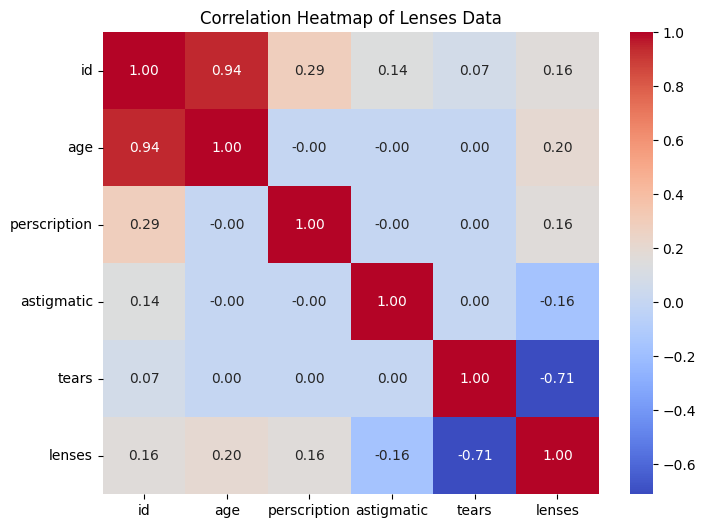

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(lenses.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Lenses Data')
plt.show()

In [ ]:
X = lenses.drop(["lenses","id"], axis=1).values
Y = lenses["lenses"].values

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=1)
X_train.shape

(16, 4)

# ***MODEL***

In [ ]:
# Khởi tạo và huấn luyện cây quyết định
print("--- Huấn luyện cây quyết định ---")
tree = DecisionTree(max_depth=3, min_samples_split=2)
tree.fit(X_train, Y_train)
print("Huấn luyện hoàn tất.\n")

# Khởi tạo và huấn luyện cây quyết định
print("--- Huấn luyện cây quyết định ---")
# Tăng max_depth lên một chút có thể giúp cây học tốt hơn với dữ liệu phân loại
tree = DecisionTree(max_depth=5, min_samples_split=2, min_impurity_decrease=0.0)
tree.fit(X_train, Y_train)
print("Huấn luyện hoàn tất.\n")

# Dự đoán trên tập kiểm thử
print("--- Đánh giá mô hình ---")
y_pred = tree.predict(X_test)

print(f"Nhãn thực tế trên tập kiểm thử: {Y_test}")
print(f"Nhãn dự đoán trên tập kiểm thử: {y_pred}")

# Dự đoán trên tập huấn luyện (chỉ để kiểm tra độ khớp)
y_train_pred = tree.predict(X_train)
train_accuracy = accuracy_score(Y_train, y_train_pred)
print(f"Độ chính xác trên tập huấn luyện: {train_accuracy:.4f}")

# Tính độ chính xác
accuracy = accuracy_score(Y_test, y_pred)
print(f"\nĐộ chính xác trên tập kiểm thử: {accuracy:.4f}")


--- Huấn luyện cây quyết định ---
Huấn luyện hoàn tất.

--- Huấn luyện cây quyết định ---
Huấn luyện hoàn tất.

--- Đánh giá mô hình ---
Nhãn thực tế trên tập kiểm thử: [2 3 1 3 3 3 3 3]
Nhãn dự đoán trên tập kiểm thử: [2 3 1 3 3 2 3 3]
Độ chính xác trên tập huấn luyện: 1.0000

Độ chính xác trên tập kiểm thử: 0.8750


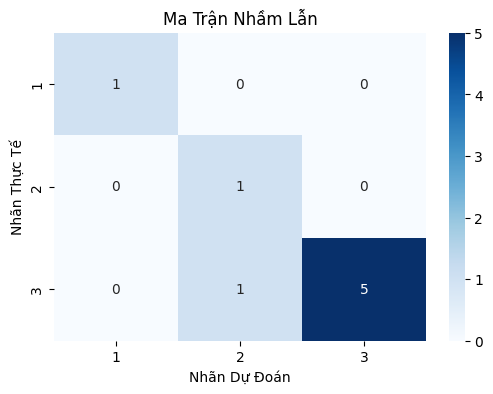


Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       0.50      1.00      0.67         1
           3       1.00      0.83      0.91         6

    accuracy                           0.88         8
   macro avg       0.83      0.94      0.86         8
weighted avg       0.94      0.88      0.89         8



In [ ]:
# Hiển thị Confusion Matrix
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(Y_test), yticklabels=np.unique(Y_test))
plt.xlabel('Nhãn Dự Đoán')
plt.ylabel('Nhãn Thực Tế')
plt.title('Ma Trận Nhầm Lẫn')
plt.show()

# Hiển thị báo cáo phân loại (Classification Report)
print("\nClassification Report:")
print(classification_report(Y_test, y_pred))


# ***MODEL SKLEARN***

In [ ]:
tree = DecisionTreeClassifier(criterion="gini")
tree.fit(X_train, Y_train)

y_pred_train = tree.predict(X_train)
y_pred = tree.predict(X_test)# this is the predictive model

accuracy_train = accuracy_score(Y_train, y_pred_train)
accuracy_test = accuracy_score(Y_test, y_pred)

print("ACCURACY: TRAIN=%.4f TEST=%.4f" % (accuracy_train,accuracy_test))

ACCURACY: TRAIN=1.0000 TEST=0.8750


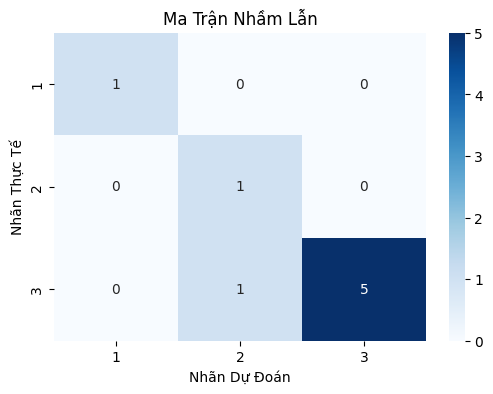


Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       0.50      1.00      0.67         1
           3       1.00      0.83      0.91         6

    accuracy                           0.88         8
   macro avg       0.83      0.94      0.86         8
weighted avg       0.94      0.88      0.89         8



In [ ]:
# Tính ma trận nhầm lẫn
cm = confusion_matrix(Y_test, y_pred)

# Hiển thị ma trận nhầm lẫn sử dụng seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(Y_test), yticklabels=np.unique(Y_test))
plt.xlabel('Nhãn Dự Đoán')
plt.ylabel('Nhãn Thực Tế')
plt.title('Ma Trận Nhầm Lẫn')
plt.show()

# Hiển thị báo cáo phân loại (Classification Report)
print("\nClassification Report:")
print(classification_report(Y_test, y_pred))